## Cell 1 – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Cell 2 – Load Datasets

In [2]:
customers = pd.read_csv("../data/cleaned/customers.csv")
sales_header = pd.read_csv("../data/cleaned/sales_header.csv")
sales_lines = pd.read_csv("../data/cleaned/sales_lines.csv")

print("Customers:", customers.shape)
print("Sales Header:", sales_header.shape)
print("Sales Lines:", sales_lines.shape)

Customers: (500, 17)
Sales Header: (20000, 15)
Sales Lines: (130402, 9)


## Cell 3 – Dataset Overview

In [3]:
datasets = {"customers": customers, "sales_header": sales_header, "sales_lines": sales_lines}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print(df.columns.tolist())


CUSTOMERS
Rows: 500
Columns: 17
['customer_id', 'customer_type', 'industry_segment', 'city', 'state', 'pincode', 'region', 'branch_id', 'credit_limit', 'current_balance', 'payment_terms', 'customer_since', 'last_purchase_date', 'total_purchase_value', 'customer_rating', 'last_purchase_date_year', 'last_purchase_date_month']

SALES_HEADER
Rows: 20000
Columns: 15
['so_id', 'customer_id', 'branch_id', 'order_date', 'delivery_date', 'order_status', 'payment_terms', 'total_order_value', 'total_gst_amount', 'grand_total', 'sales_channel', 'order_date_year', 'order_date_month', 'delivery_date_year', 'delivery_date_month']

SALES_LINES
Rows: 130402
Columns: 9
['so_id', 'line_number', 'product_id', 'quantity', 'unit_price', 'gst_rate', 'line_total', 'gst_amount', 'line_grand_total']


## Cell 4 – Customer Profile

In [4]:
print("Number of customers:", customers["customer_id"].nunique())
print("\nCustomer types:")
print(customers["customer_type"].value_counts())
print("\nIndustry segments:")
print(customers["industry_segment"].value_counts())
print("\nRegions:")
print(customers["region"].value_counts())

Number of customers: 500

Customer types:
customer_type
Government     114
Corporate      104
Dealer          99
Fleet Owner     95
Retail          88
Name: count, dtype: int64

Industry segments:
industry_segment
Mining            98
Logistics         96
Construction      90
Infrastructure    79
Manufacturing     70
Rental            67
Name: count, dtype: int64

Regions:
region
South         158
West          151
East           87
North          82
Central        11
North East     11
Name: count, dtype: int64


## Cell 5 – Customer Financial Overview

In [5]:
customers[["credit_limit", "current_balance", "total_purchase_value", "customer_rating"]].describe()

,credit_limit,current_balance,total_purchase_value,customer_rating
count,5.000000e+02,5.000000e+02,5.000000e+02,500.00000
mean,4.915253e+05,2.466805e+05,2.480429e+06,2.98200
std,3.720844e+05,2.588476e+05,1.454708e+06,1.40913
min,1.055200e+04,6.300000e+01,5.173000e+03,1.00000
25%,2.106442e+05,3.739025e+04,1.221794e+06,2.00000
50%,4.171450e+05,1.785700e+05,2.546906e+06,3.00000
75%,7.136942e+05,3.488998e+05,3.755662e+06,4.00000
max,1.493816e+06,1.435105e+06,4.998438e+06,5.00000


## Cell 6 – Top Customers

In [6]:
top_customers = customers[[
    "customer_id", "customer_type", "industry_segment", "region",
    "total_purchase_value", "customer_rating"
]].sort_values("total_purchase_value", ascending=False).head(10)

top_customers

,customer_id,customer_type,industry_segment,region,total_purchase_value,customer_rating
266,C0267,Fleet Owner,Infrastructure,South,4998438,3
394,C0395,Corporate,Manufacturing,East,4995587,1
416,C0417,Fleet Owner,Mining,East,4991661,3
433,C0434,Corporate,Mining,Central,4961157,4
274,C0275,Fleet Owner,Construction,West,4940277,5
320,C0321,Retail,Logistics,South,4937062,2
411,C0412,Corporate,Infrastructure,East,4934990,3
207,C0208,Fleet Owner,Logistics,North,4909280,4
451,C0452,Fleet Owner,Mining,South,4909073,1
118,C0119,Government,Manufacturing,West,4897663,4


## Cell 7 – Prepare Customer Sales Data

In [7]:
customer_sales = sales_header.merge(
    customers[["customer_id", "customer_type", "industry_segment", "region", "branch_id"]],
    on="customer_id", how="left", suffixes=("", "_customer")
)
customer_sales["order_date"] = pd.to_datetime(customer_sales["order_date"], errors="coerce")
customer_sales.head()

,so_id,customer_id,branch_id,order_date,delivery_date,order_status,payment_terms,total_order_value,total_gst_amount,grand_total,sales_channel,order_date_year,order_date_month,delivery_date_year,delivery_date_month,customer_type,industry_segment,region,branch_id_customer
0,So-990591,C0070,Ahm001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,2022,5,2022,5,Government,Logistics,West,Ahm001
1,So-431510,C0031,Kol001,2022-05-01,2022-05-08,Delivered,Advance,2194850,609423.0,2804273.0,Dealer Network,2022,5,2022,5,Government,Mining,East,Kol001
2,So-495859,C0013,Ahm001,2023-10-01,2023-10-02,Delivered,Advance,2620800,733824.0,3354624.0,Online,2023,10,2023,10,Dealer,Construction,West,Ahm001
3,So-745068,C0382,Hyd001,2021-10-04,2021-10-09,Delivered,Advance,1094950,292961.0,1387911.0,Online,2021,10,2021,10,Retail,Manufacturing,South,Hyd001
4,So-175713,C0472,Chn001,2024-10-31,2024-11-04,Delivered,Net 45,1250,225.0,1475.0,Counter Sale,2024,10,2024,11,Dealer,Manufacturing,South,Chn001


## Cell 8 – Customer Purchase Metrics

In [8]:
customer_metrics = customer_sales.groupby("customer_id").agg(
    frequency=("so_id", "nunique"),
    monetary=("grand_total", "sum"),
    average_order_value=("grand_total", "mean")
).reset_index()

customer_metrics.head()

,customer_id,frequency,monetary,average_order_value
0,C0001,40,67052288.0,1.676307e+06
1,C0002,56,77917319.2,1.391381e+06
2,C0003,40,50921823.2,1.273046e+06
3,C0004,47,62484367.6,1.329455e+06
4,C0005,51,85668379.8,1.679772e+06


## Cell 9 – Calculate Recency

In [9]:
reference_date = customer_sales["order_date"].max()

customer_recency = customer_sales.groupby("customer_id").agg(
    last_order_date=("order_date", "max")
).reset_index()

customer_recency["recency"] = (
    reference_date - customer_recency["last_order_date"]
).dt.days

customer_recency.head()

,customer_id,last_order_date,recency
0,C0001,2024-12-25,6
1,C0002,2024-11-28,33
2,C0003,2024-10-30,62
3,C0004,2024-12-31,0
4,C0005,2024-10-04,88


## Cell 10 – Create RFM Dataset

In [10]:
rfm = customer_recency.merge(customer_metrics, on="customer_id", how="left")

rfm[["recency", "frequency", "monetary", "average_order_value"]].describe()

,recency,frequency,monetary,average_order_value
count,500.00000,500.000000,5.000000e+02,5.000000e+02
mean,54.64400,40.000000,6.484951e+07,1.621705e+06
std,49.89931,6.385417,1.393278e+07,2.381869e+05
min,0.00000,26.000000,2.907614e+07,1.023040e+06
25%,18.00000,36.000000,5.475734e+07,1.454254e+06
50%,41.50000,39.000000,6.373248e+07,1.614674e+06
75%,78.25000,44.000000,7.357568e+07,1.770940e+06
max,288.00000,63.000000,1.093606e+08,2.446280e+06


## Cell 11 – Create RFM Scores

In [11]:
rfm["R_score"] = pd.qcut(rfm["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_total"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
)

rfm.head()

,customer_id,last_order_date,recency,frequency,monetary,average_order_value,R_score,F_score,M_score,RFM_total,RFM_score
0,C0001,2024-12-25,6,40,67052288.0,1.676307e+06,5,3,3,11,533
1,C0002,2024-11-28,33,56,77917319.2,1.391381e+06,3,5,5,13,355
2,C0003,2024-10-30,62,40,50921823.2,1.273046e+06,2,3,1,6,231
3,C0004,2024-12-31,0,47,62484367.6,1.329455e+06,5,5,3,13,553
4,C0005,2024-10-04,88,51,85668379.8,1.679772e+06,2,5,5,12,255


## Cell 12 – Customer Segmentation

In [12]:
def segment_customer(row):
    if row["RFM_total"] >= 13:
        return "Champions"
    elif row["RFM_total"] >= 10:
        return "Loyal Customers"
    elif row["RFM_total"] >= 7:
        return "Potential Customers"
    elif row["RFM_total"] >= 5:
        return "At Risk"
    else:
        return "Inactive Customers"

rfm["customer_segment"] = rfm.apply(segment_customer, axis=1)
rfm["customer_segment"].value_counts()

customer_segment
Loyal Customers        159
Potential Customers    149
At Risk                 84
Champions               72
Inactive Customers      36
Name: count, dtype: int64

## Cell 13 – Add Customer Details

In [13]:
rfm = rfm.merge(
    customers[[
        "customer_id", "customer_type", "industry_segment", "city", "state",
        "region", "branch_id", "credit_limit", "current_balance", "customer_rating"
    ]],
    on="customer_id", how="left"
)

rfm.head()

,customer_id,last_order_date,recency,frequency,monetary,average_order_value,R_score,F_score,M_score,RFM_total,...,customer_segment,customer_type,industry_segment,city,state,region,branch_id,credit_limit,current_balance,customer_rating
0,C0001,2024-12-25,6,40,67052288.0,1.676307e+06,5,3,3,11,...,Loyal Customers,Retail,Construction,Kolkata,West Bengal,East,Kol001,45896,43284,4
1,C0002,2024-11-28,33,56,77917319.2,1.391381e+06,3,5,5,13,...,Champions,Fleet Owner,Manufacturing,Hyderabad,Telangana,South,Hyd001,531506,426735,2
2,C0003,2024-10-30,62,40,50921823.2,1.273046e+06,2,3,1,6,...,At Risk,Government,Logistics,Surat,Gujarat,West,Del001,1306933,733495,2
3,C0004,2024-12-31,0,47,62484367.6,1.329455e+06,5,5,3,13,...,Champions,Fleet Owner,Logistics,Chennai,Tamil Nadu,South,Chn001,506336,250255,3
4,C0005,2024-10-04,88,51,85668379.8,1.679772e+06,2,5,5,12,...,Loyal Customers,Dealer,Construction,Ahmedabad,Gujarat,West,Ahm001,380783,183927,2


## Cell 14 – Segment Analysis

In [14]:
segment_summary = rfm.groupby("customer_segment").agg(
    customers=("customer_id", "nunique"),
    total_revenue=("monetary", "sum"),
    average_revenue=("monetary", "mean"),
    average_frequency=("frequency", "mean"),
    average_recency=("recency", "mean"),
    average_order_value=("average_order_value", "mean")
).reset_index()

segment_summary.sort_values("total_revenue", ascending=False)

,customer_segment,customers,total_revenue,average_revenue,average_frequency,average_recency,average_order_value
3,Loyal Customers,159,1.120948e+10,7.049988e+07,43.119497,42.320755,1.642227e+06
4,Potential Customers,149,9.091198e+09,6.101475e+07,37.362416,54.570470,1.646686e+06
1,Champions,72,6.041589e+09,8.391095e+07,48.666667,18.277778,1.728027e+06
0,At Risk,84,4.374184e+09,5.207362e+07,34.785714,73.464286,1.503079e+06
2,Inactive Customers,36,1.708303e+09,4.745286e+07,31.972222,138.194444,1.491820e+06


## Cell 15 – High-Value and At-Risk Customers

In [15]:
high_value_customers = rfm.sort_values("monetary", ascending=False).head(10)
at_risk_customers = rfm[rfm["customer_segment"] == "At Risk"].sort_values("monetary", ascending=False).head(20)

print("Top High-Value Customers")
display(high_value_customers[[
    "customer_id", "customer_type", "industry_segment", "frequency", "monetary", "customer_segment"
]])

print("\nAt-Risk Customers")
display(at_risk_customers[[
    "customer_id", "customer_type", "industry_segment", "recency", "frequency", "monetary"
]])

Top High-Value Customers


,customer_id,customer_type,industry_segment,frequency,monetary,customer_segment
152,C0153,Retail,Rental,59,109360638.6,Champions
482,C0483,Corporate,Rental,53,108672502.0,Champions
287,C0288,Dealer,Infrastructure,63,107119652.2,Loyal Customers
494,C0495,Fleet Owner,Infrastructure,52,105717422.2,Champions
419,C0420,Retail,Rental,54,105420085.2,Champions
239,C0240,Corporate,Manufacturing,50,104286776.8,Champions
206,C0207,Corporate,Rental,51,101737768.4,Loyal Customers
341,C0342,Dealer,Infrastructure,44,100153639.6,Loyal Customers
465,C0466,Retail,Manufacturing,52,99913868.2,Champions
358,C0359,Fleet Owner,Mining,52,99895983.4,Champions



At-Risk Customers


,customer_id,customer_type,industry_segment,recency,frequency,monetary
212,C0213,Fleet Owner,Rental,122,32,68039047.6
484,C0485,Fleet Owner,Rental,91,34,66922042.0
497,C0498,Fleet Owner,Construction,134,30,66413930.8
227,C0228,Government,Construction,112,36,65812402.2
29,C0030,Corporate,Construction,120,38,64370910.6
46,C0047,Corporate,Rental,128,36,64303432.2
255,C0256,Corporate,Infrastructure,103,34,63561255.0
418,C0419,Fleet Owner,Logistics,92,34,63139736.8
157,C0158,Corporate,Infrastructure,96,37,62074622.2
366,C0367,Fleet Owner,Logistics,57,31,61649463.4


## Cell 16 – Industry, Region and Branch Analysis

In [16]:
industry_analysis = rfm.groupby("industry_segment").agg(
    customers=("customer_id", "nunique"),
    total_revenue=("monetary", "sum"),
    average_revenue=("monetary", "mean")
).reset_index()

region_analysis = rfm.groupby("region").agg(
    customers=("customer_id", "nunique"),
    total_revenue=("monetary", "sum"),
    average_revenue=("monetary", "mean")
).reset_index()

branch_analysis = rfm.groupby("branch_id").agg(
    customers=("customer_id", "nunique"),
    total_revenue=("monetary", "sum"),
    average_order_value=("average_order_value", "mean")
).reset_index()

display(industry_analysis.sort_values("total_revenue", ascending=False))
display(region_analysis.sort_values("total_revenue", ascending=False))
display(branch_analysis.sort_values("total_revenue", ascending=False))

,industry_segment,customers,total_revenue,average_revenue
2,Logistics,96,6.144984e+09,6.401025e+07
4,Mining,98,6.030783e+09,6.153861e+07
0,Construction,90,5.733328e+09,6.370365e+07
1,Infrastructure,79,5.210899e+09,6.596075e+07
3,Manufacturing,70,4.787099e+09,6.838713e+07
5,Rental,67,4.517661e+09,6.742777e+07


,region,customers,total_revenue,average_revenue
4,South,158,1.033107e+10,6.538651e+07
5,West,151,9.506449e+09,6.295661e+07
1,East,87,5.688253e+09,6.538222e+07
2,North,82,5.536616e+09,6.751971e+07
0,Central,11,7.018619e+08,6.380563e+07
3,North East,11,6.605066e+08,6.004606e+07


,branch_id,customers,total_revenue,average_order_value
1,Chn001,102,6.615942e+09,1.635073e+06
4,Kol001,96,6.100494e+09,1.616530e+06
0,Ahm001,88,5.616586e+09,1.626590e+06
2,Del001,71,4.926515e+09,1.662658e+06
5,Pun001,75,4.766708e+09,1.604536e+06
3,Hyd001,68,4.398510e+09,1.578814e+06


## Cell 17 – Sales Channel Analysis

In [17]:
channel_analysis = customer_sales.groupby("sales_channel").agg(
    orders=("so_id", "nunique"),
    customers=("customer_id", "nunique"),
    total_revenue=("grand_total", "sum"),
    average_order_value=("grand_total", "mean")
).reset_index()

channel_analysis.sort_values("total_revenue", ascending=False)

,sales_channel,orders,customers,total_revenue,average_order_value
2,Field Sales,5036,500,8.210171e+09,1.630296e+06
0,Counter Sale,5014,500,8.172855e+09,1.630007e+06
1,Dealer Network,5028,500,8.107783e+09,1.612527e+06
3,Online,4922,500,7.933945e+09,1.611935e+06


## Cell 18 – Customer Segment Visualization

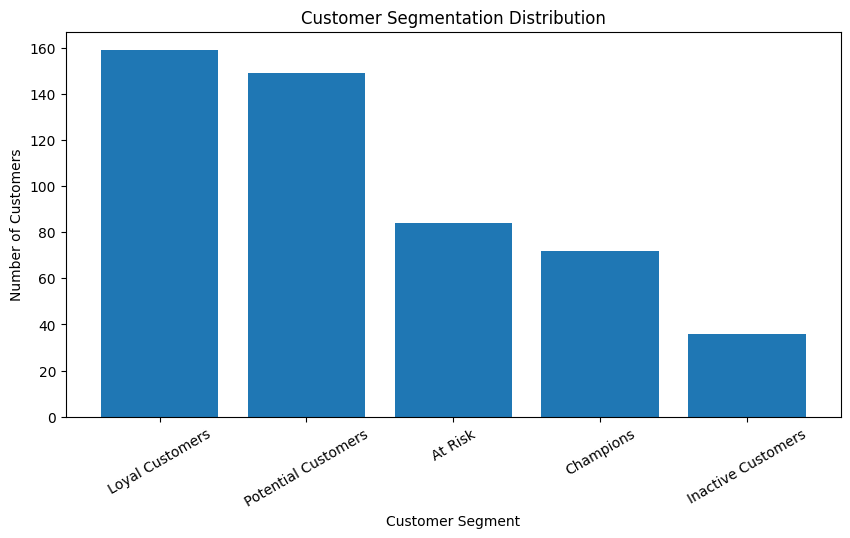

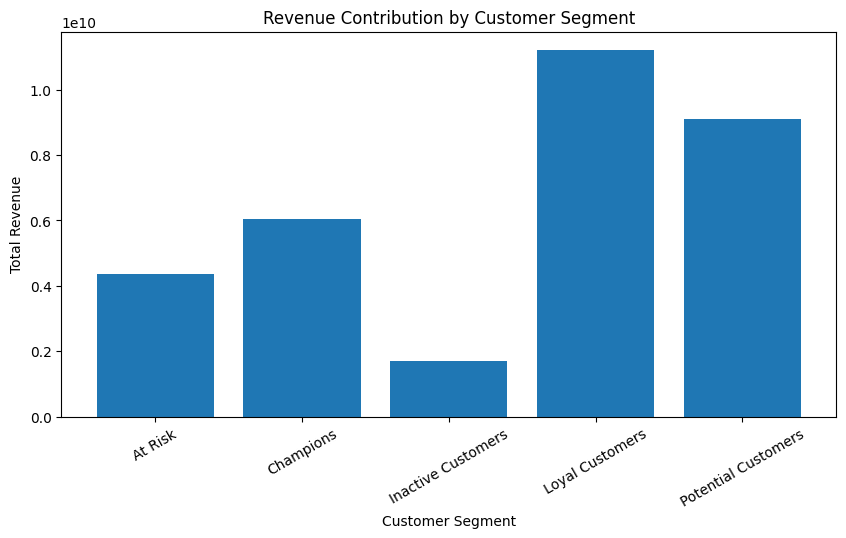

In [18]:
segment_counts = rfm["customer_segment"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segmentation Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

segment_revenue = rfm.groupby("customer_segment")["monetary"].sum()

plt.figure(figsize=(10, 5))
plt.bar(segment_revenue.index, segment_revenue.values)
plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()

## Cell 19 – Customer KPI Dashboard and Insights

In [19]:
total_customers = rfm["customer_id"].nunique()
total_revenue = rfm["monetary"].sum()
average_customer_revenue = rfm["monetary"].mean()
average_order_value = customer_sales["grand_total"].mean()

champions = (rfm["customer_segment"] == "Champions").sum()
at_risk = (rfm["customer_segment"] == "At Risk").sum()
inactive = (rfm["customer_segment"] == "Inactive Customers").sum()

customer_kpis = pd.DataFrame({
    "KPI": [
        "Total Customers", "Total Customer Revenue", "Average Customer Revenue",
        "Average Order Value", "Champions", "At Risk Customers", "Inactive Customers"
    ],
    "Value": [
        total_customers, total_revenue, average_customer_revenue,
        average_order_value, champions, at_risk, inactive
    ]
})

display(customer_kpis)

print("\nBusiness Insights")
print("-" * 40)
print(f"Total customers analysed: {total_customers}")
print(f"Total customer revenue: {total_revenue:,.2f}")
print(f"Champion customers: {champions}")
print(f"At-risk customers: {at_risk}")
print(f"Inactive customers: {inactive}")

,KPI,Value
0,Total Customers,5.000000e+02
1,Total Customer Revenue,3.242475e+10
2,Average Customer Revenue,6.484951e+07
3,Average Order Value,1.621238e+06
4,Champions,7.200000e+01
5,At Risk Customers,8.400000e+01
6,Inactive Customers,3.600000e+01



Business Insights
----------------------------------------
Total customers analysed: 500
Total customer revenue: 32,424,754,555.80
Champion customers: 72
At-risk customers: 84
Inactive customers: 36


## Cell 20 – Final Output, Recommendations and Validation

In [20]:
customer_analytics = rfm[[
    "customer_id", "customer_type", "industry_segment", "city", "state",
    "region", "branch_id", "recency", "frequency", "monetary",
    "average_order_value", "R_score", "F_score", "M_score",
    "RFM_score", "RFM_total", "customer_segment",
    "credit_limit", "current_balance", "customer_rating"
]].sort_values("monetary", ascending=False).reset_index(drop=True)

customer_analytics.to_csv("../data/cleaned/customer_analytics.csv", index=False)
segment_summary.to_csv("../data/cleaned/customer_segment_summary.csv", index=False)
channel_analysis.to_csv("../data/cleaned/customer_channel_analysis.csv", index=False)
branch_analysis.to_csv("../data/cleaned/customer_branch_analysis.csv", index=False)

print("Week 8 outputs saved successfully.")
print("\nRecommended business actions:")
for i, recommendation in enumerate([
    "Maintain strong relationships with Champion customers.",
    "Monitor At Risk customers for retention opportunities.",
    "Review inactive customers for re-engagement opportunities.",
    "Focus customer development on high-value segments.",
    "Monitor branch and sales-channel customer performance."
], start=1):
    print(f"{i}. {recommendation}")

print("\nFinal validation:")
print("Customers analysed:", customer_analytics["customer_id"].nunique())
print("Segments identified:", customer_analytics["customer_segment"].nunique())
print("Rows in final dataset:", len(customer_analytics))
print("Missing values:", customer_analytics.isnull().sum().sum())

Week 8 outputs saved successfully.

Recommended business actions:
1. Maintain strong relationships with Champion customers.
2. Monitor At Risk customers for retention opportunities.
3. Review inactive customers for re-engagement opportunities.
4. Focus customer development on high-value segments.
5. Monitor branch and sales-channel customer performance.

Final validation:
Customers analysed: 500
Segments identified: 5
Rows in final dataset: 500
Missing values: 0
